## **AI-Powered Citizen Grievance Analysis System**

## Objective
This project aims to analyze citizen complaints using Natural Language Processing (NLP) and Machine Learning techniques. The system classifies complaints into categories and helps identify patterns in public issues.

## Tools & Technologies
- Python
- Pandas, NumPy
- NLP (NLTK)
- Machine Learning (Scikit-learn)
- Visualization (Matplotlib, Seaborn)

#  Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

# **Dataset Load**

In [2]:
df = pd.read_csv("311_Service_Requests.csv")
df.head()

/tmp/ipykernel_2207/525135959.py:1: DtypeWarning: Columns (48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("311_Service_Requests.csv")


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [3]:
df = df[['Complaint Type']]
df.rename(columns={'Complaint Type':'complaint'}, inplace=True)
df['category'] = df['complaint']

# **Text Cleaning**

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['complaint'].apply(clean_text)

# **Tokenization**

In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

def tokenize_text(text):
    return word_tokenize(str(text))

df['tokens'] = df['clean_text'].apply(tokenize_text)

df[['clean_text', 'tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,clean_text,tokens
0,noise streetsidewalk,"[noise, streetsidewalk]"
1,blocked driveway,"[blocked, driveway]"
2,blocked driveway,"[blocked, driveway]"
3,illegal parking,"[illegal, parking]"
4,illegal parking,"[illegal, parking]"


# **Stopwords Removal**

In [8]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# **Lemmatization**

In [9]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

[nltk_data] Downloading package wordnet to /root/nltk_data...


# **Final Text**

In [10]:
df['final_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   complaint   364558 non-null  object
 1   category    364558 non-null  object
 2   clean_text  364558 non-null  object
 3   tokens      364558 non-null  object
 4   final_text  364558 non-null  object
dtypes: object(5)
memory usage: 13.9+ MB


In [12]:
df.describe()

,complaint,category,clean_text,tokens,final_text
count,364558,364558,364558,364558,364558
unique,24,24,24,24,24
top,Blocked Driveway,Blocked Driveway,blocked driveway,"[blocked, driveway]",blocked driveway
freq,100881,100881,100881,100881,100881


# **Category Distribution**

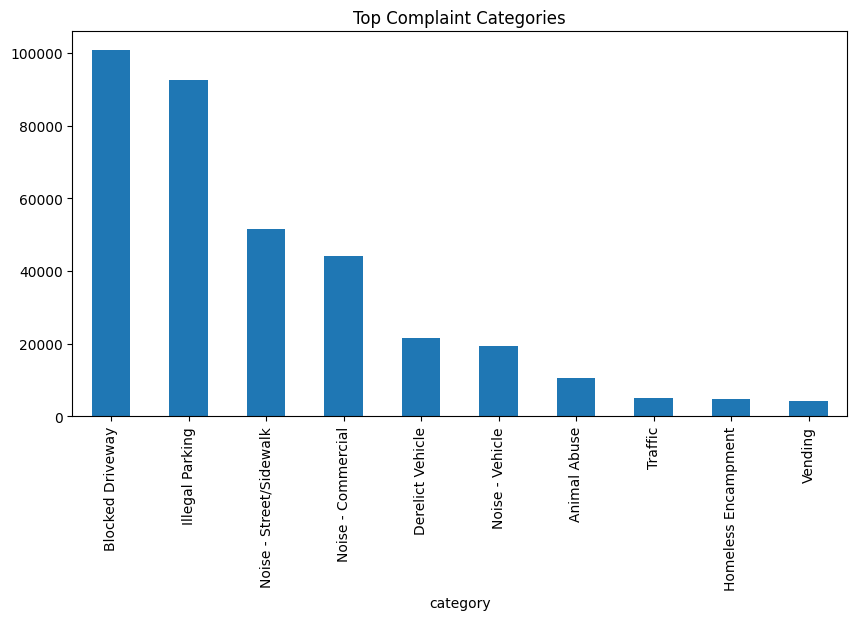

In [13]:
plt.figure(figsize=(10,5))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Complaint Categories")
plt.savefig("category_distribution.png")
plt.show()

# **Complaint Length**

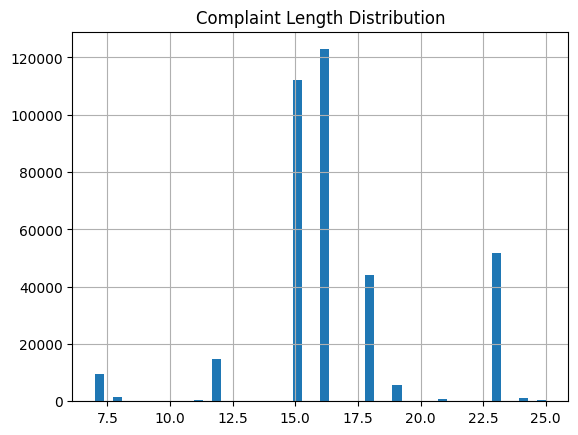

In [14]:
df['length'] = df['complaint'].apply(len)

df['length'].hist(bins=50)
plt.title("Complaint Length Distribution")
plt.savefig("length_distribution.png")
plt.show()

# **WordCloud**

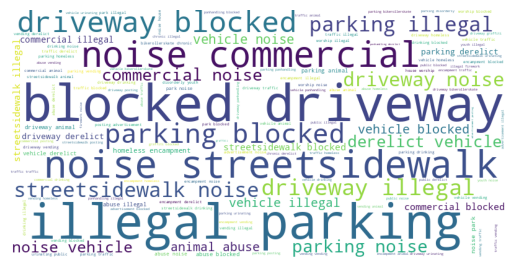

In [15]:
from wordcloud import WordCloud

text = " ".join(df['final_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.savefig("wordcloud.png")
plt.show()

# **Insights**

- Most complaints belong to a few dominant categories
- Certain issues like noise, water, and waste appear frequently
- Complaint text length varies, indicating both short and detailed complaints
- WordCloud shows common problem keywords faced by citizens

# **Clean Data**

In [17]:
df_final = df[['final_text', 'category']]

In [18]:
df_final.to_csv("cleaned_complaints.csv", index=False)